In [35]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation

In [36]:
def get_results_imgs(simulation, iterations=50,  type1 = 'random', type2 = 'random', type3 = 'random', save_dir=None, title=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0).cpu().numpy())
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0).cpu().numpy())

    # get the final population sizes
    # results = []
    # results.append(pop1_size[-1])
    # results.append(pop2_size[-1])
    # results.append(pop3_size[-1])

    # results.append(pop1_size[-1] / fitness_total * 100)
    # results.append(pop2_size[-1] / fitness_total * 100)
    # results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    string_results = '\n'
    string_results+='Final population fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1]}\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1]}\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1]}\n\n'
        
    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]
    string_results+=f'Total fitness: {fitness_total}\n\n'

    string_results+='Final population %\'s fitness:\n'
    string_results+=f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%\n'
    string_results+=f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%\n'

    print(string_results)


    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'Type 1 : {type1}'),
        Patch(facecolor='blue', edgecolor='b', label=f'Type 2 : {type2}'),
        Patch(facecolor='green', edgecolor='g', label=f'Type 3 : {type3}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final population distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_final_distr.pdf'), bbox_inches='tight')

    plt.show()

    # Plot the population size over time
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'Population 1 : {type1}', color='red')
    plt.plot(np.arange(iterations), pop2_size, '--', label=f'Population 2 : {type2}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'Population 3 : {type3}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f'{title}_time_plot.pdf'), bbox_inches='tight')
    plt.show()

    return string_results

Creating simulation with parameters: bonus_0_0 - fitness_donation: 0.0 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 37.749366760253906
Population 2: random - 23.652738571166992
Population 3: random - 21.01549530029297

Total fitness: 82.4176025390625

Final population %'s fitness:
Population 1: attacking - 45.80%
Population 2: random - 28.70%
Population 3: random - 25.50%



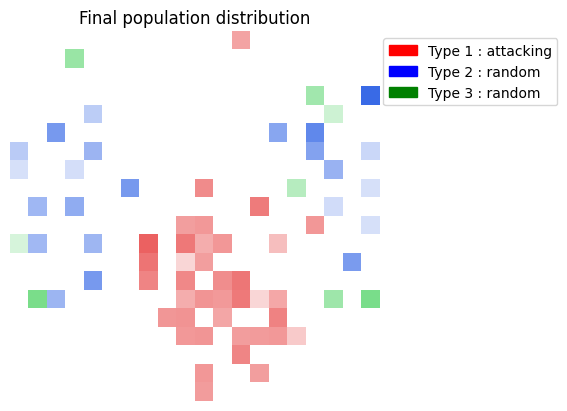

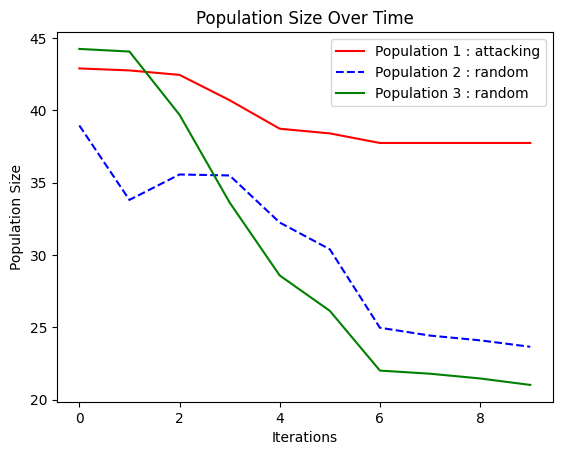

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 40.451045989990234
Population 2: random - 20.211214065551758
Population 3: random - 28.9194393157959

Total fitness: 89.58170318603516

Final population %'s fitness:
Population 1: giving - 45.16%
Population 2: random - 22.56%
Population 3: random - 32.28%



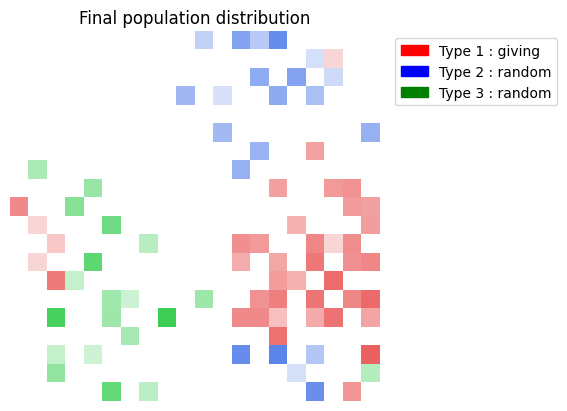

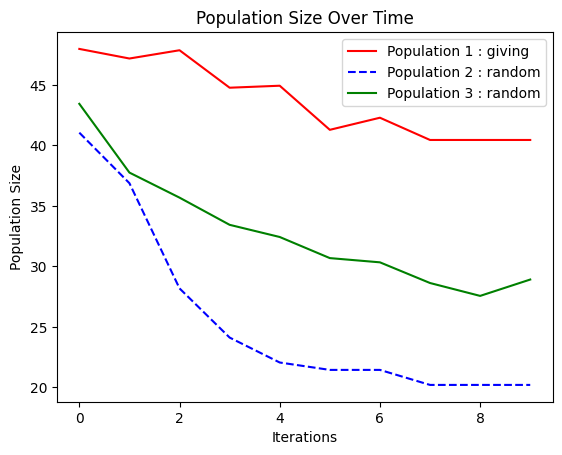

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 27.92132568359375
Population 2: random - 15.7454833984375
Population 3: random - 31.856760025024414

Total fitness: 75.52356719970703

Final population %'s fitness:
Population 1: complete - 36.97%
Population 2: random - 20.85%
Population 3: random - 42.18%



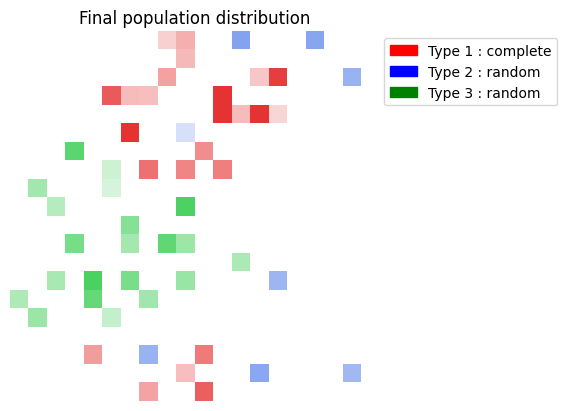

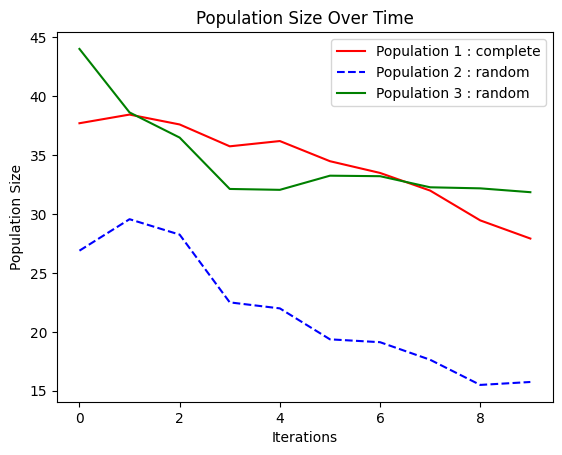

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 43.586734771728516
Population 2: giving - 51.71795654296875
Population 3: attacking - 46.464778900146484

Total fitness: 141.76947021484375

Final population %'s fitness:
Population 1: complete - 30.74%
Population 2: giving - 36.48%
Population 3: attacking - 32.77%



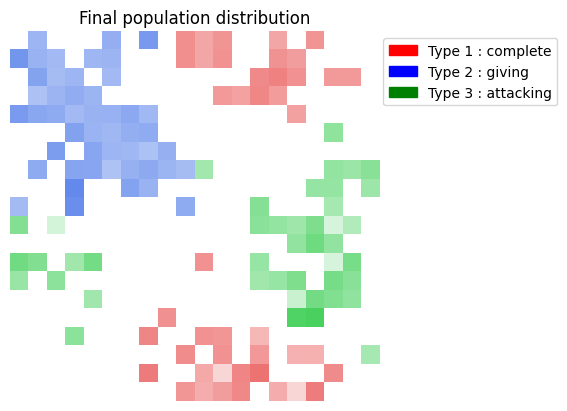

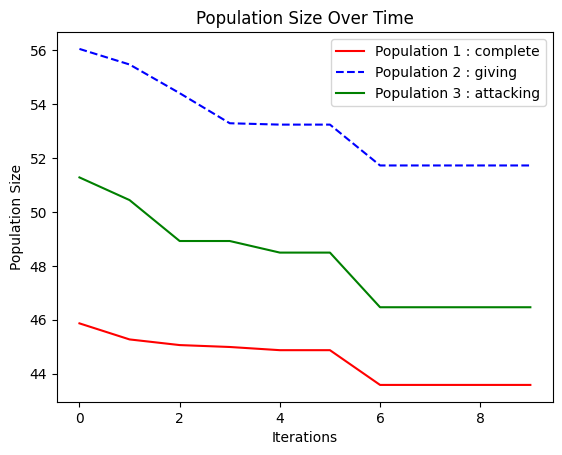

Creating simulation with parameters: bonus_0_1 - fitness_donation: 0.0 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 31.217975616455078
Population 2: random - 17.031455993652344
Population 3: random - 19.84536361694336

Total fitness: 68.09479522705078

Final population %'s fitness:
Population 1: attacking - 45.84%
Population 2: random - 25.01%
Population 3: random - 29.14%



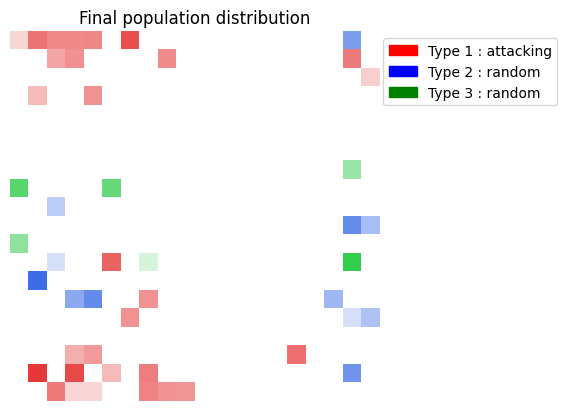

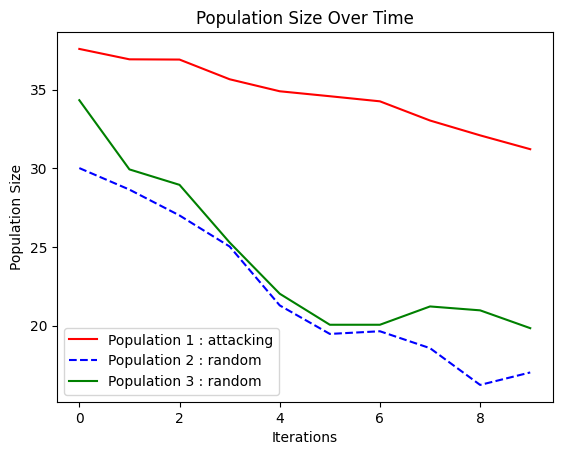

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 56.296119689941406
Population 2: random - 25.824373245239258
Population 3: random - 27.385007858276367

Total fitness: 109.50550079345703

Final population %'s fitness:
Population 1: giving - 51.41%
Population 2: random - 23.58%
Population 3: random - 25.01%



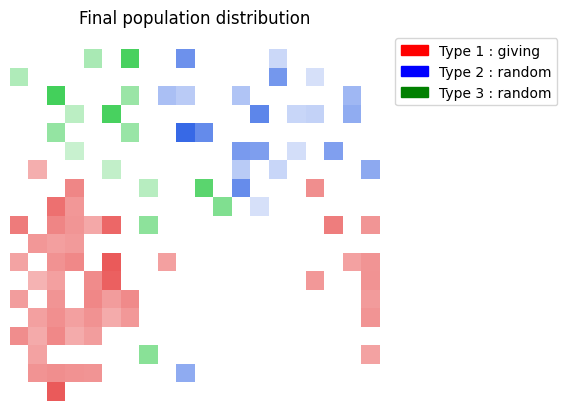

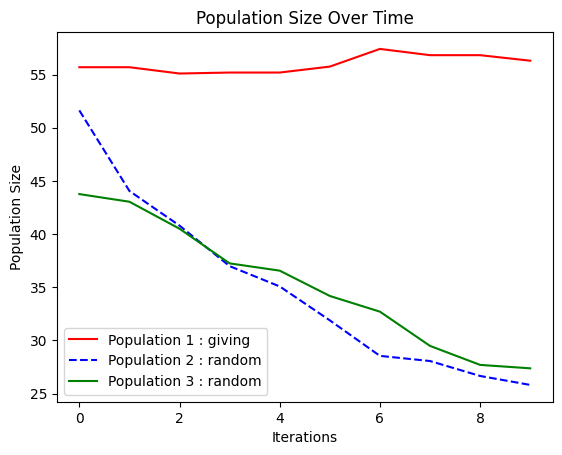

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 43.072181701660156
Population 2: random - 20.270709991455078
Population 3: random - 27.449790954589844

Total fitness: 90.79267883300781

Final population %'s fitness:
Population 1: complete - 47.44%
Population 2: random - 22.33%
Population 3: random - 30.23%



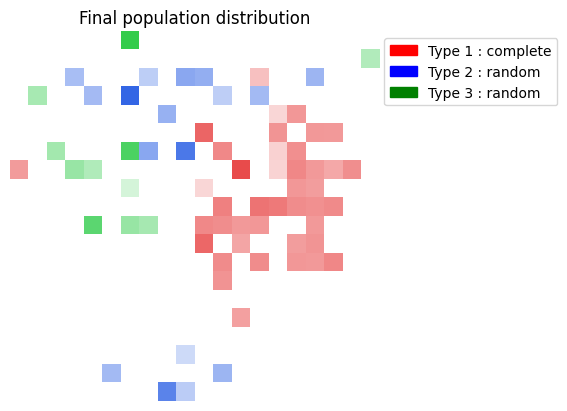

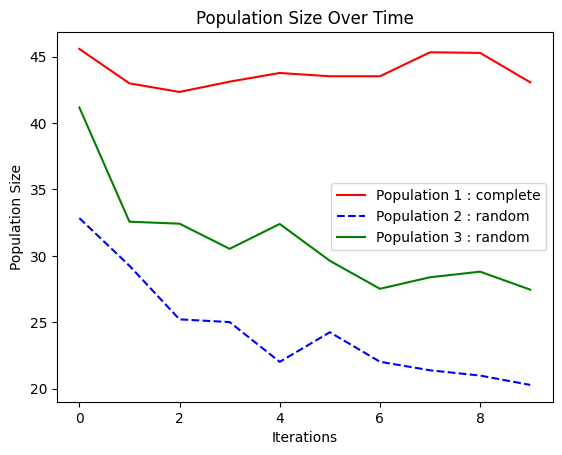

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 36.0609130859375
Population 2: giving - 19.683387756347656
Population 3: attacking - 32.743106842041016

Total fitness: 88.48741149902344

Final population %'s fitness:
Population 1: complete - 40.75%
Population 2: giving - 22.24%
Population 3: attacking - 37.00%



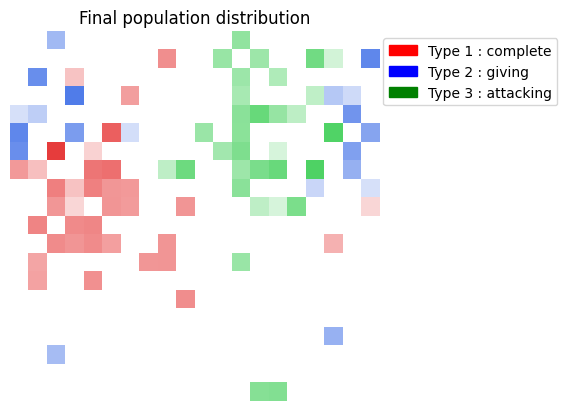

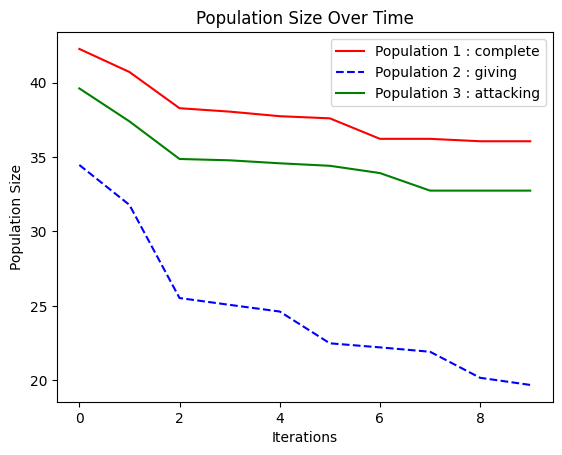

Creating simulation with parameters: bonus_1_0 - fitness_donation: 0.1 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 48.114749908447266
Population 2: random - 24.693012237548828
Population 3: random - 24.327341079711914

Total fitness: 97.13510131835938

Final population %'s fitness:
Population 1: attacking - 49.53%
Population 2: random - 25.42%
Population 3: random - 25.04%



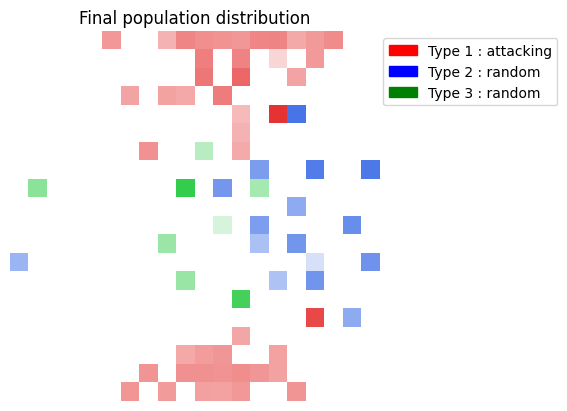

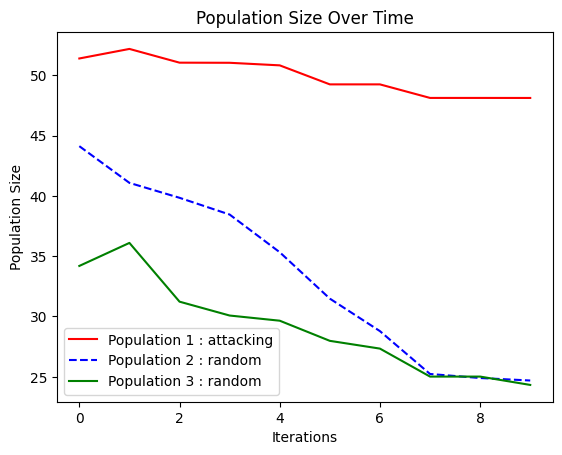

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 55.614952087402344
Population 2: random - 21.94731330871582
Population 3: random - 22.80509376525879

Total fitness: 100.36735534667969

Final population %'s fitness:
Population 1: giving - 55.41%
Population 2: random - 21.87%
Population 3: random - 22.72%



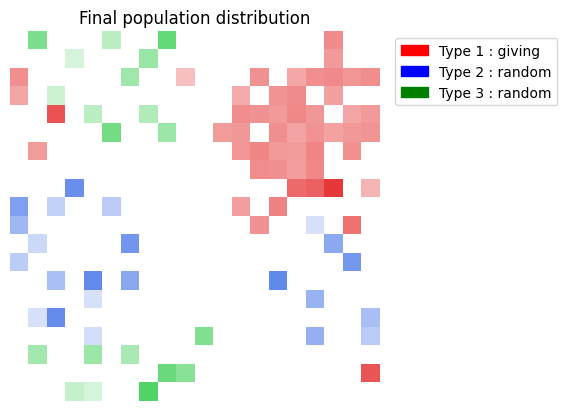

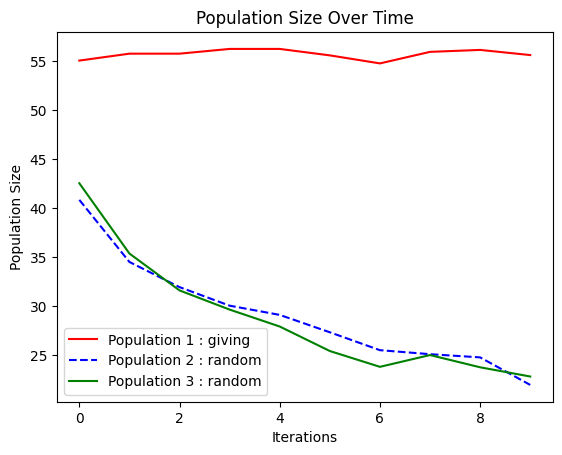

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 48.549739837646484
Population 2: random - 28.87093734741211
Population 3: random - 25.08248519897461

Total fitness: 102.50315856933594

Final population %'s fitness:
Population 1: complete - 47.36%
Population 2: random - 28.17%
Population 3: random - 24.47%



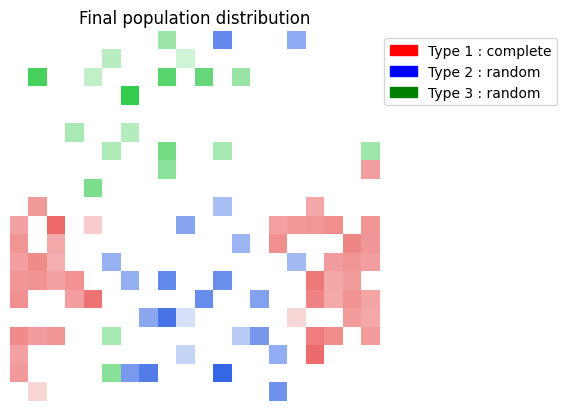

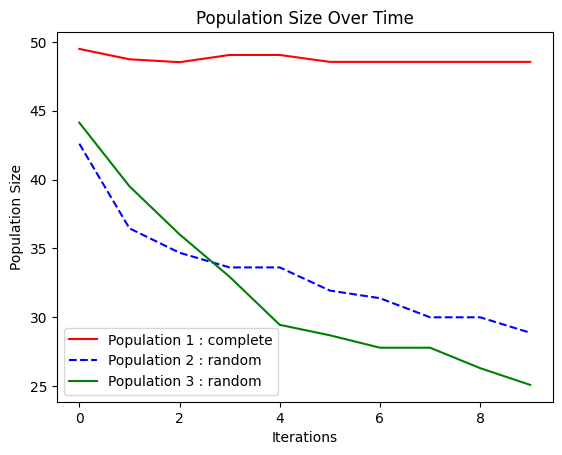

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 37.29134750366211
Population 2: giving - 40.86182403564453
Population 3: attacking - 29.81511688232422

Total fitness: 107.9682846069336

Final population %'s fitness:
Population 1: complete - 34.54%
Population 2: giving - 37.85%
Population 3: attacking - 27.61%



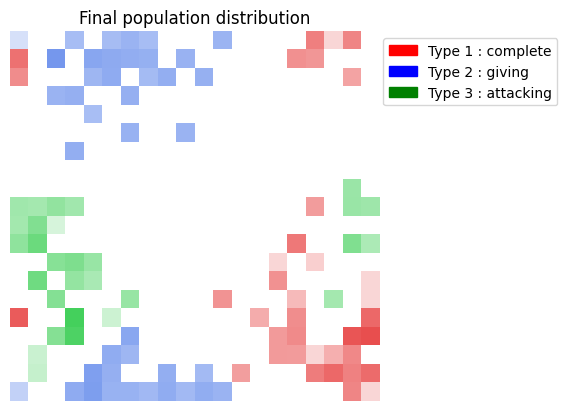

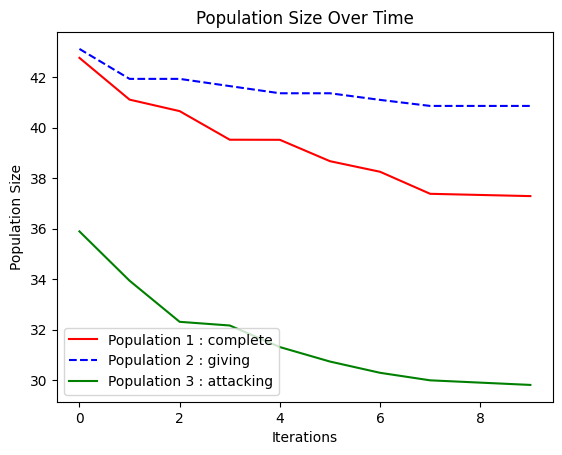

Creating simulation with parameters: bonus_1_1 - fitness_donation: 0.1 - fitness_growth: 0.1
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 26.09070587158203
Population 2: random - 22.962894439697266
Population 3: random - 21.069965362548828

Total fitness: 70.12356567382812

Final population %'s fitness:
Population 1: attacking - 37.21%
Population 2: random - 32.75%
Population 3: random - 30.05%



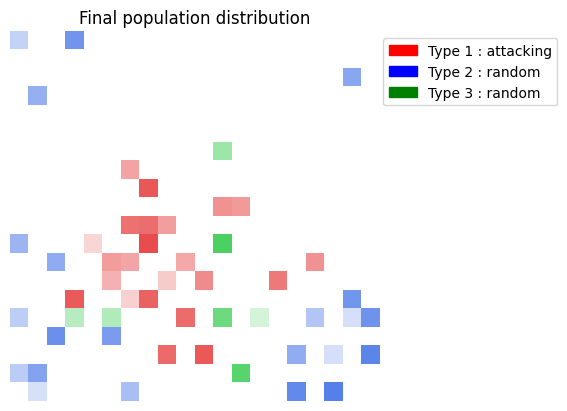

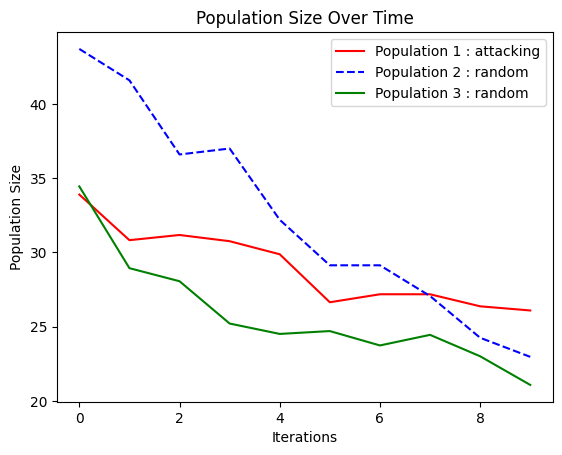

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 47.37152862548828
Population 2: random - 23.037080764770508
Population 3: random - 36.12649154663086

Total fitness: 106.53509521484375

Final population %'s fitness:
Population 1: giving - 44.47%
Population 2: random - 21.62%
Population 3: random - 33.91%



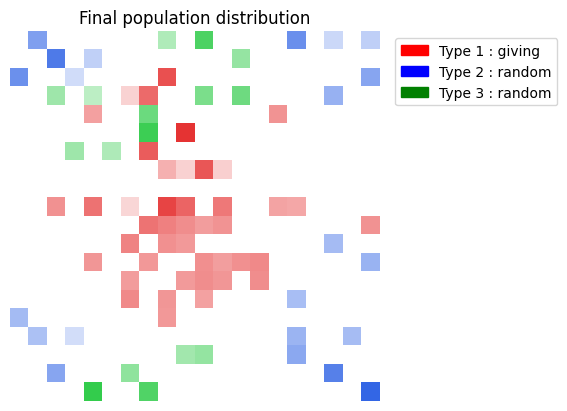

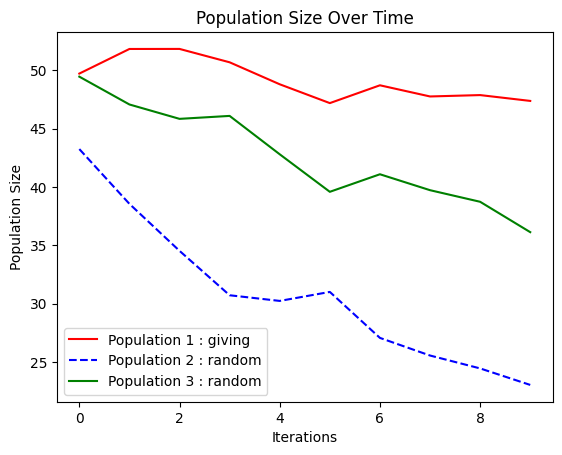

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 28.42655372619629
Population 2: random - 28.544891357421875
Population 3: random - 21.25497817993164

Total fitness: 78.22642517089844

Final population %'s fitness:
Population 1: complete - 36.34%
Population 2: random - 36.49%
Population 3: random - 27.17%



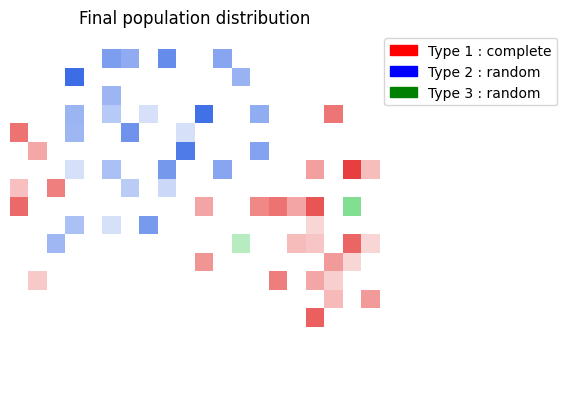

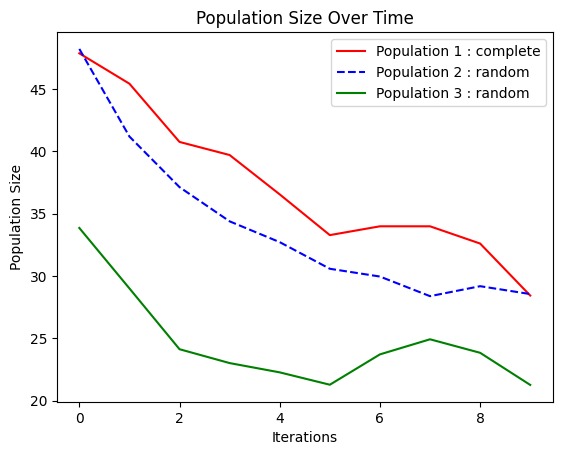

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 35.21332931518555
Population 2: giving - 27.657155990600586
Population 3: attacking - 42.889625549316406

Total fitness: 105.7601089477539

Final population %'s fitness:
Population 1: complete - 33.30%
Population 2: giving - 26.15%
Population 3: attacking - 40.55%



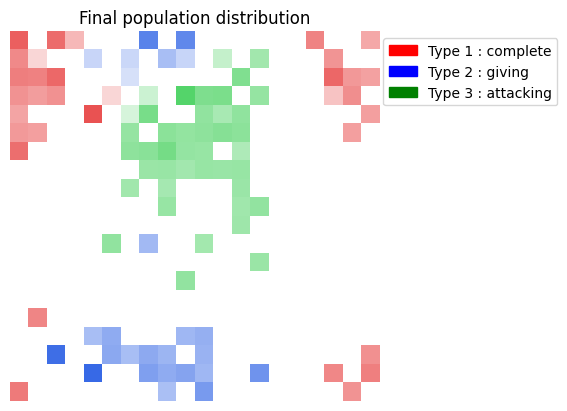

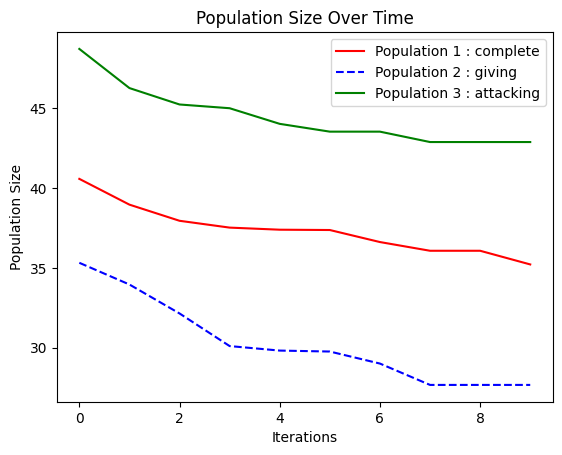

Creating simulation with parameters: bonus_2_0 - fitness_donation: 0.2 - fitness_growth: 0.0
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 28.199783325195312
Population 2: random - 23.280256271362305
Population 3: random - 25.54608917236328

Total fitness: 77.02613067626953

Final population %'s fitness:
Population 1: attacking - 36.61%
Population 2: random - 30.22%
Population 3: random - 33.17%



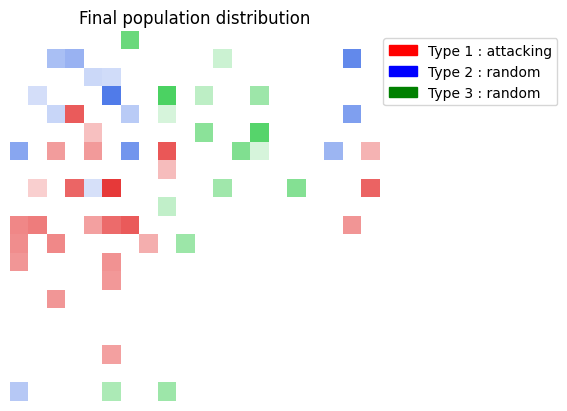

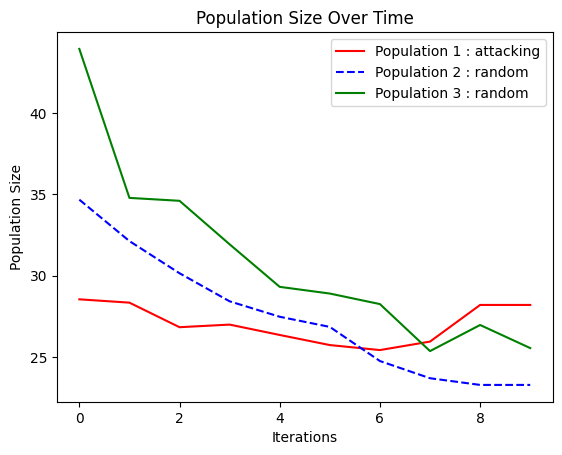

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 38.49618911743164
Population 2: random - 23.538162231445312
Population 3: random - 26.591379165649414

Total fitness: 88.625732421875

Final population %'s fitness:
Population 1: giving - 43.44%
Population 2: random - 26.56%
Population 3: random - 30.00%



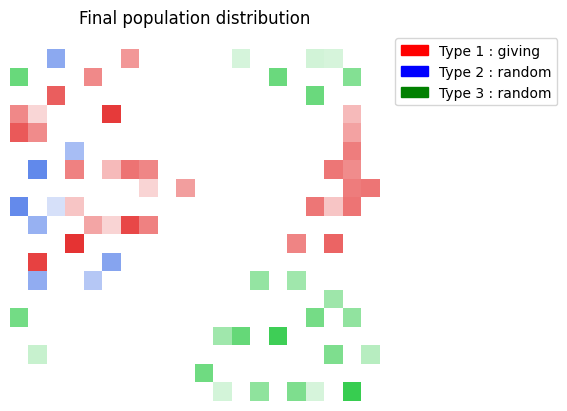

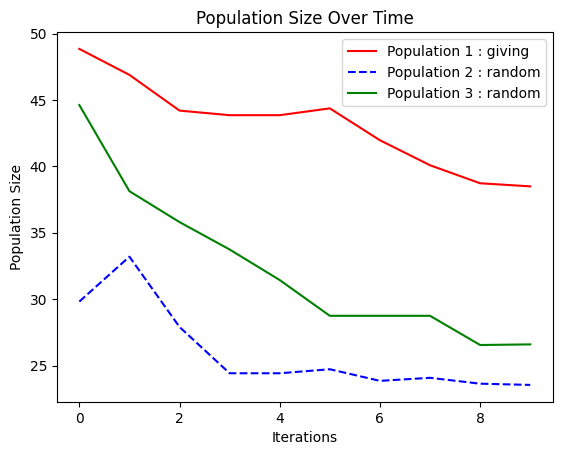

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 46.63218688964844
Population 2: random - 20.16606330871582
Population 3: random - 29.60357666015625

Total fitness: 96.40182495117188

Final population %'s fitness:
Population 1: complete - 48.37%
Population 2: random - 20.92%
Population 3: random - 30.71%



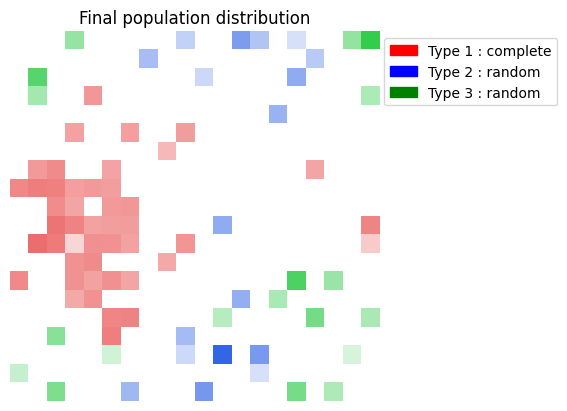

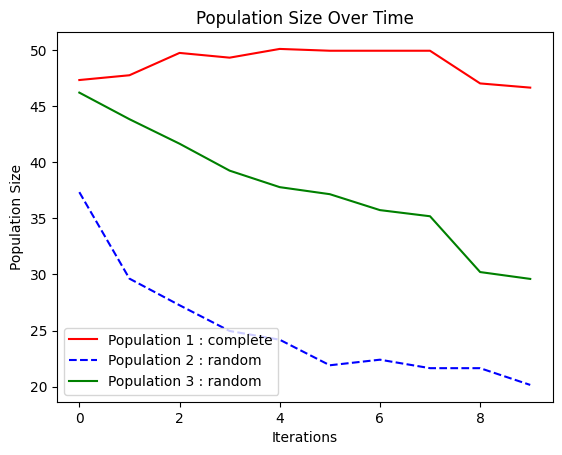

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 46.51298522949219
Population 2: giving - 24.33123779296875
Population 3: attacking - 26.505874633789062

Total fitness: 97.35009765625

Final population %'s fitness:
Population 1: complete - 47.78%
Population 2: giving - 24.99%
Population 3: attacking - 27.23%



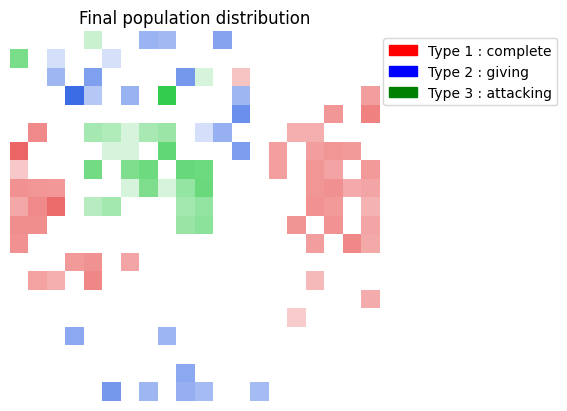

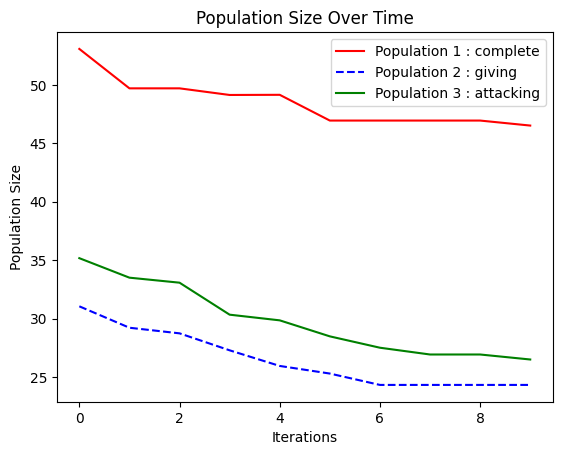

Creating simulation with parameters: bonus_2_1 - fitness_donation: 0.0 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 49.75395584106445
Population 2: random - 30.414165496826172
Population 3: random - 36.1392707824707

Total fitness: 116.30738830566406

Final population %'s fitness:
Population 1: attacking - 42.78%
Population 2: random - 26.15%
Population 3: random - 31.07%



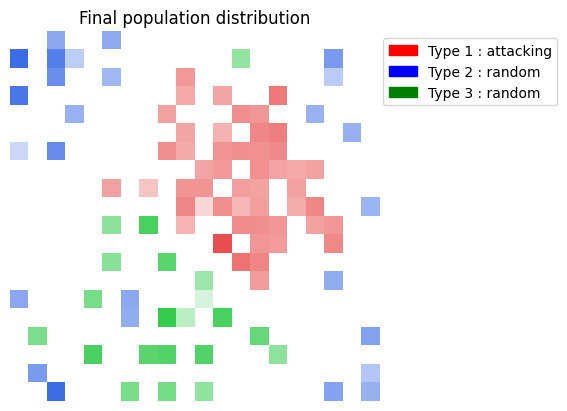

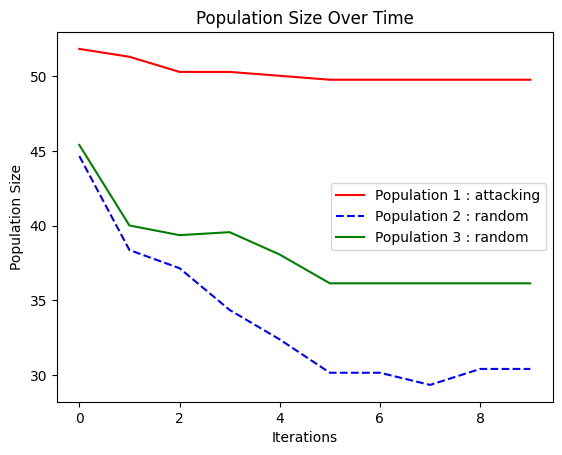

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 54.20981979370117
Population 2: random - 32.68241882324219
Population 3: random - 26.729990005493164

Total fitness: 113.62223052978516

Final population %'s fitness:
Population 1: giving - 47.71%
Population 2: random - 28.76%
Population 3: random - 23.53%



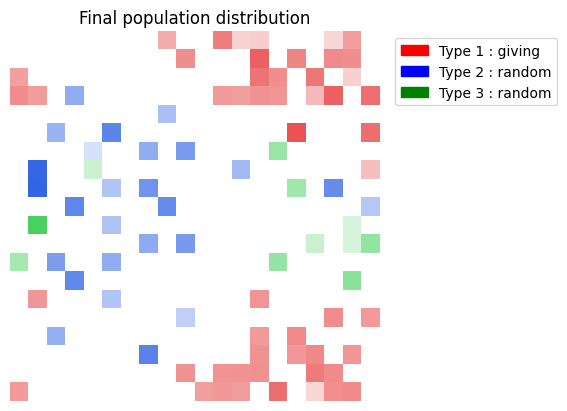

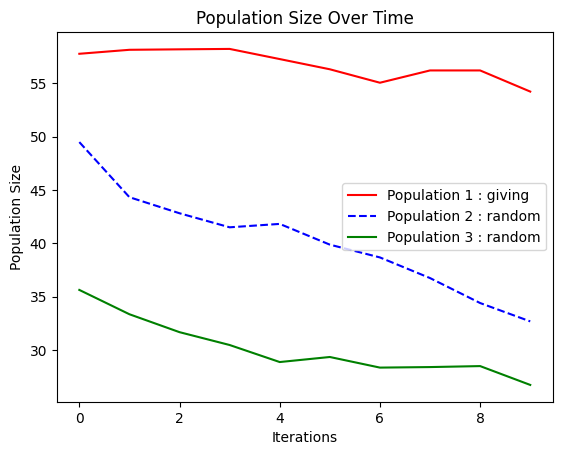

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 48.800994873046875
Population 2: random - 25.514469146728516
Population 3: random - 23.61162757873535

Total fitness: 97.92708587646484

Final population %'s fitness:
Population 1: complete - 49.83%
Population 2: random - 26.05%
Population 3: random - 24.11%



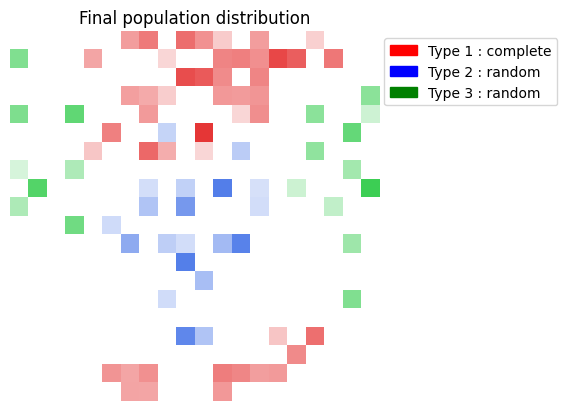

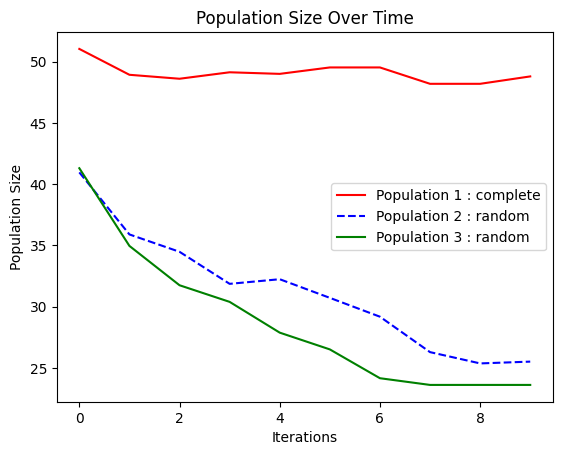

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 49.841270446777344
Population 2: giving - 50.01799011230469
Population 3: attacking - 36.22251892089844

Total fitness: 136.081787109375

Final population %'s fitness:
Population 1: complete - 36.63%
Population 2: giving - 36.76%
Population 3: attacking - 26.62%



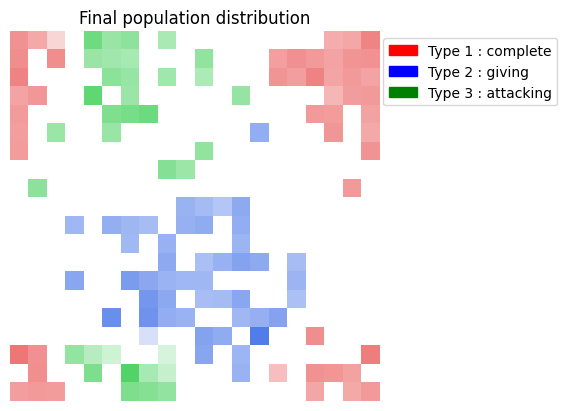

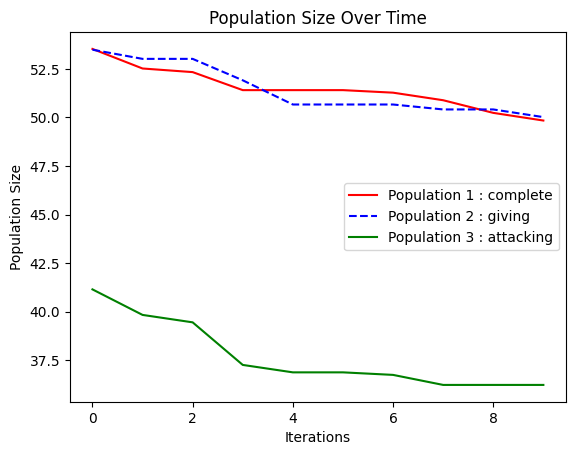

Creating simulation with parameters: bonus_2_2 - fitness_donation: 0.2 - fitness_growth: 0.2
Creating simulation: attack vs random

Final population fitness:
Population 1: attacking - 42.889869689941406
Population 2: random - 22.426692962646484
Population 3: random - 19.992706298828125

Total fitness: 85.30926513671875

Final population %'s fitness:
Population 1: attacking - 50.28%
Population 2: random - 26.29%
Population 3: random - 23.44%



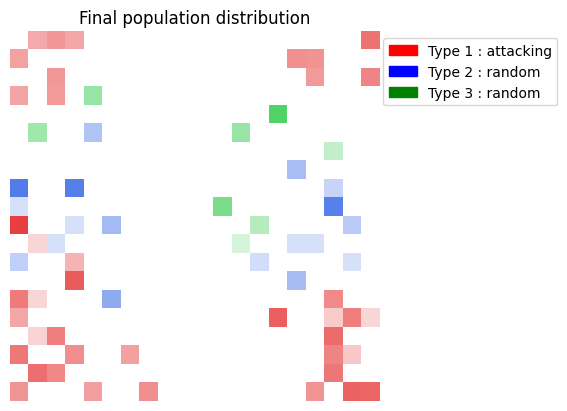

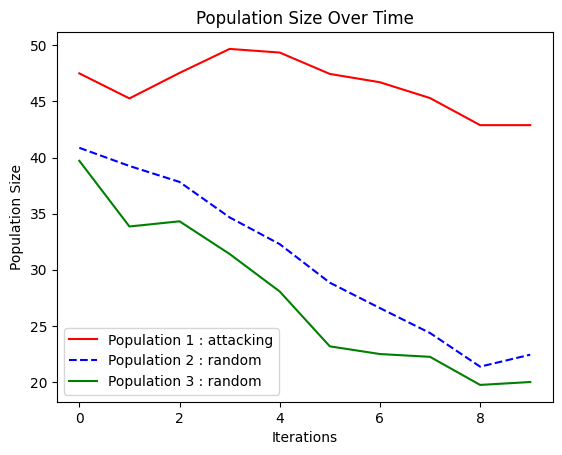

Creating simulation: giving vs random

Final population fitness:
Population 1: giving - 36.716609954833984
Population 2: random - 22.703414916992188
Population 3: random - 26.37371826171875

Total fitness: 85.79374694824219

Final population %'s fitness:
Population 1: giving - 42.80%
Population 2: random - 26.46%
Population 3: random - 30.74%



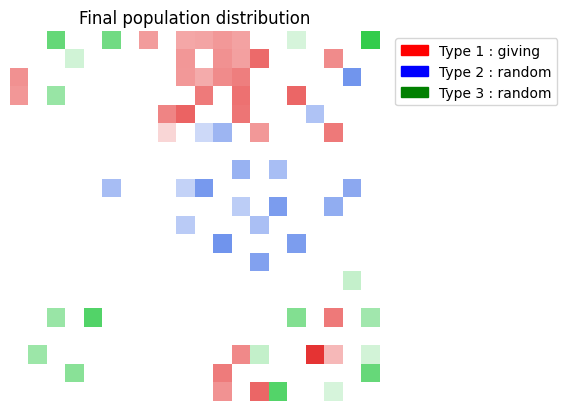

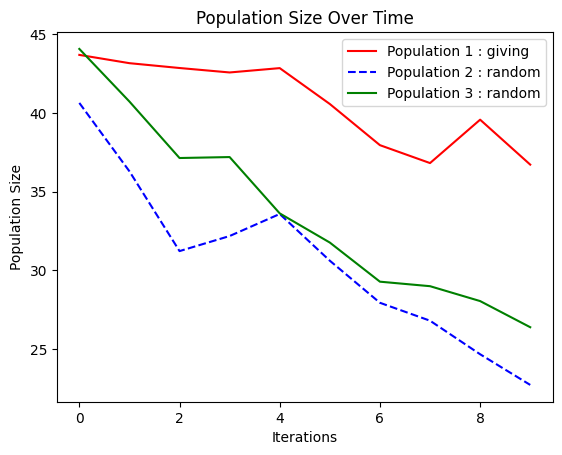

Creating simulation: complete vs random

Final population fitness:
Population 1: complete - 37.45355987548828
Population 2: random - 18.437339782714844
Population 3: random - 24.27961540222168

Total fitness: 80.17051696777344

Final population %'s fitness:
Population 1: complete - 46.72%
Population 2: random - 23.00%
Population 3: random - 30.28%



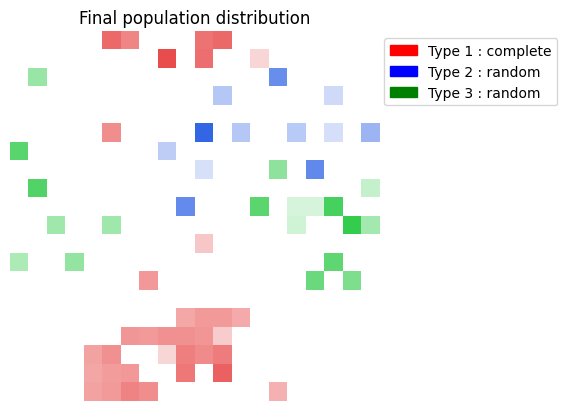

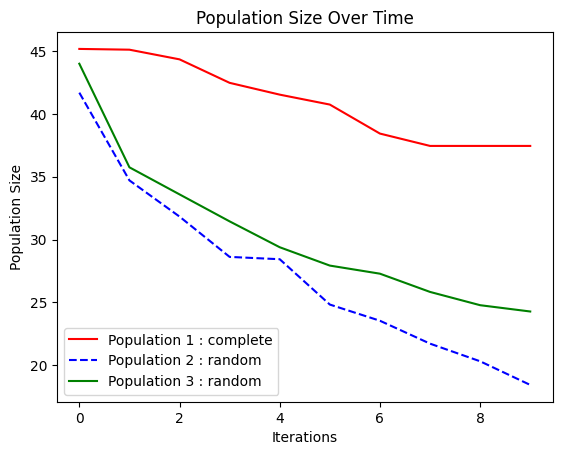

Creating simulation: complete vs giving vs attacking

Final population fitness:
Population 1: complete - 38.016578674316406
Population 2: giving - 34.736183166503906
Population 3: attacking - 15.80599594116211

Total fitness: 88.55876159667969

Final population %'s fitness:
Population 1: complete - 42.93%
Population 2: giving - 39.22%
Population 3: attacking - 17.85%



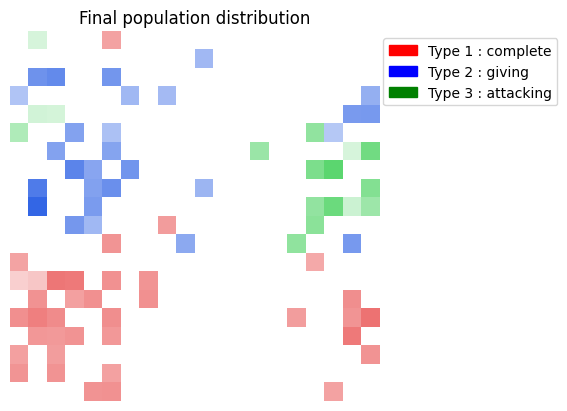

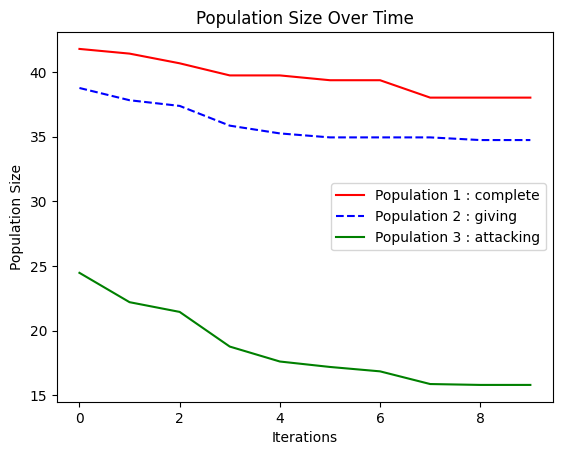

In [37]:
# if save_dir is None, the images will not be saved

simulation_parameters = [('bonus_0_0', 0.0, 0.0), ('bonus_0_1', 0.0, 0.1), ('bonus_1_0', 0.1, 0.0), ('bonus_1_1', 0.1, 0.1), ('bonus_2_0', 0.2, 0.0), ('bonus_2_1', 0.0, 0.2), ('bonus_2_2', 0.2, 0.2)]

all_results_string = 'pop1 total fitness; pop2 total fitness; pop2 total fitness; pop1 \% fitness; pop 2 \% fitness; pop 3 \% fitness \n'

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)

# Number of iterations 
iterations = 10

# Simulation parameters
nb_batches = 1
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for tup in simulation_parameters:

    sub_dir_name = tup[0]
    fitness_donation = tup[1]
    fitness_growth = tup[2]

    title = f"don_{fitness_donation}_growth_{fitness_growth}"

    print(f"Creating simulation with parameters: {sub_dir_name} - fitness_donation: {fitness_donation} - fitness_growth: {fitness_growth}")

    # Create the simulation "attack vs random"

    print("Creating simulation: attack vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'attackVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None
    results = get_results_imgs(simulation, iterations=iterations, save_dir=tmp_dir, type1='attacking', title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - attack vs random\n{results}\n"
        all_results_string += results_string + "\n"


    # Create the simulation "giving vs random"
    print("Creating simulation: giving vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'givingVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='giving', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - giving vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "complete vs random"
    print("Creating simulation: complete vs random")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsRandom')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', save_dir=tmp_dir, title=title)
    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs random\n{results}\n"
        all_results_string += results_string + "\n"

    # Create the simulation "giving vs attacking vs complete"
    print("Creating simulation: complete vs giving vs attacking")
    simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                    populations=populations, device=device, 
                                    FITNESS_DONATION_BONUS=fitness_donation, FITNESS_GROWTH_VALUE=fitness_growth)
    simulation.reset()

    if SAVE_DIR is not None:
        tmp_dir = os.path.join(SAVE_DIR, 'completeVsGivingVsAttacking')
        os.makedirs(tmp_dir, exist_ok=True)
    else:
        tmp_dir = None

    results = get_results_imgs(simulation, iterations=iterations, type1='complete', type2='giving', type3='attacking', save_dir=tmp_dir, title=title)

    if SAVE_DIR is not None:
        results_string = f"Simulation: {title} - complete vs giving vs attacking\n{results}\n"
        all_results_string += results_string + "\n"

if SAVE_DIR is not None:
    results_txt_path = os.path.join(SAVE_DIR, "results_summary.txt")
    with open(results_txt_path, "w") as f:
        f.write(all_results_string)
